In [ ]:
import os
import sys
import torch
import functools
import numpy as np
import pandas as pd
import gc

sys.path.insert(0, '..')
from src import prompts
from src.activation import collect_activations, extract_refusal_directions, calculate_concept_projection
from src.load_data import get_morality_scenarios, get_grammar_scenarios, get_economic_scenarios, get_items

from torch import Tensor
from typing import List
from transformer_lens import HookedTransformer
# from transformer_lens.model_bridge import TransformerBridge
from transformers import AutoTokenizer, AutoModelForCausalLM
from jaxtyping import Int

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

##### Configuration

In [29]:
MODEL_PATH = [
    'Qwen/Qwen2.5-7B-Instruct',
    # 'Qwen/Qwen2.5-32b-instruct',

    # 'Qwen/qwen3-8b',
    # 'Qwen/qwen3-14b',
    # 'Qwen/qwen3-32b',

    # 'google/gemma-2-9b-it',
    # 'google/gemma-2-27b-it',

    # 'google/gemma-3-4b-it',
    # 'google/gemma-3-12b-it',
    # 'google/gemma-3-27b-it',

    # 'mistralai/mistral-small-24b-instruct-2501',
]

DEVICE = 'cuda'
BATCH_SIZE = 16

GRAND_DIR = '../stimuli/Grand_et_al'
GRAND_STIMULI = ['animals_size', 'names_age', 'states_temperature', 'weather_wetness']

GRAMMAR_CSV    = '../stimuli/Grammar Correction.csv'
TEST_VALUE_CSV = '../stimuli/test_value.csv'

N_SAMPLES = 100
RANDOM_SEED = 42

PLOTTING_MODE = True

In [ ]:
NUM_LAYERS_BY_MODEL = {
    'Qwen2.5-7B-Instruct':             28,
    'Qwen2.5-32B-Instruct':            64,

    'Qwen3-8B':                        36,
    'Qwen3-14B':                       40,
    'Qwen3-32B':                       64,

    'gemma-2-9b-it':                   42,
    'gemma-2-27b-it':                  46,

    'gemma-3-4b-it':                   34,
    'gemma-3-12b-it':                  48,
    'gemma-3-27b-it':                  62,

    'mistral-small-24b-instruct-2501': 40,
}

##### Load data

In [ ]:
import shutil
import traceback
from huggingface_hub.constants import HF_HUB_CACHE

torch.set_grad_enabled(False)


def _ci_lookup(table, model_name):
    if model_name in table:
        return table[model_name]
    for k, v in table.items():
        if k.lower() == model_name.lower():
            return v
    return None


def lookup_chat_template(model_name):
    return prompts.chat_template_for(model_name)


def lookup_num_layers(model_name):
    return _ci_lookup(NUM_LAYERS_BY_MODEL, model_name)


def delete_hf_model_cache(model_path):
    cache_name = "models--" + model_path.replace("/", "--")
    cache_path = os.path.join(HF_HUB_CACHE, cache_name)
    if os.path.exists(cache_path):
        shutil.rmtree(cache_path, ignore_errors=True)
        print(f"  removed disk cache: {cache_path}")
    else:
        print(f"  no disk cache at: {cache_path}")


def expected_output_files(model_name):
    paths = []
    for c in ('morality', 'grammar', 'economic'):
        paths.append(f"./data/{model_name}/{c}_scenarios_directions.csv")
    paths.append(f"./data/{model_name}/mg68_morality_projections.csv")
    paths.append(f"./data/{model_name}/mg68_grammar_projections.csv")
    paths.append(f"./data/{model_name}/me68_morality_projections.csv")
    paths.append(f"./data/{model_name}/me68_economic_projections.csv")
    for s in GRAND_STIMULI:
        for c in ('morality', 'grammar', 'economic'):
            paths.append(f"./data/{model_name}/grand_{s}_{c}_projections.csv")
    paths.append(f"./data/{model_name}/dillion_morality_projections.csv")
    paths.append(f"./data/{model_name}/grammar_correction_correct_projections.csv")
    paths.append(f"./data/{model_name}/grammar_correction_incorrect_projections.csv")
    paths.append(f"./data/{model_name}/test_value_economic_projections.csv")
    return paths


def is_multimodal_gemma3(model_path):
    name_lower = model_path.lower()
    if 'gemma-3' not in name_lower and 'medgemma' not in name_lower:
        return False
    if any(s in name_lower for s in ['270m', '1b', 'medgemma-27b-text']):
        return False
    return True


def load_model(model_path, device, dtype):
    if is_multimodal_gemma3(model_path):
        m = HookedTransformer.from_pretrained_no_processing(
            model_path, device=device, dtype=dtype, default_padding_side='left',
        )
    else:
        m = TransformerBridge.boot_transformers(model_path, device=device, dtype=dtype)
        m.enable_compatibility_mode(no_processing=True)
    m.tokenizer.padding_side = 'left'
    m.tokenizer.pad_token = m.tokenizer.eos_token
    return m

In [32]:
eval_items = get_items()
mg68_items = eval_items['mg68']
me68_items = eval_items['me68']
mg68_items = pd.read_csv('../exp9/data/MoralGrammar68_equalized.csv')['item'].to_list()

morality_negative_scenarios, morality_positive_scenarios = get_morality_scenarios()
grammar_negative_scenarios, grammar_positive_scenarios = get_grammar_scenarios()
economic_negative_scenarios, economic_positive_scenarios = get_economic_scenarios()

##### Load validation stimuli

In [ ]:
grammar_df = pd.read_csv(GRAMMAR_CSV)
grammar_sample = grammar_df.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)

correct_sentences   = grammar_sample['Standard English'].astype(str).tolist()
incorrect_sentences = grammar_sample['Ungrammatical Statement'].astype(str).tolist()

test_value_df = pd.read_csv(TEST_VALUE_CSV)
test_value_items = test_value_df['scenario'].astype(str).tolist()
test_values = test_value_df['value'].astype(float).values

print(f'Grammar Correction: sampled {len(grammar_sample)} rows')
print(f'test_value: loaded {len(test_value_df)} rows')

##### Per-model loop

In [33]:
if PLOTTING_MODE:
    print("[PLOTTING_MODE] skipping per-model activation extraction loop")
else:
    PROJECTION_TARGETS = {
        'morality': ('mg68', 'me68'),
        'grammar':  ('mg68',),
        'economic': ('me68',),
    }

    for current_model_path in MODEL_PATH:
        MODEL_NAME = current_model_path.split('/')[-1]
        CHAT_TEMPLATE = lookup_chat_template(MODEL_NAME)
        if CHAT_TEMPLATE is None:
            print(f"[SKIP] no CHAT_TEMPLATE for {MODEL_NAME}")
            continue
        NUM_LAYERS = lookup_num_layers(MODEL_NAME)
        if NUM_LAYERS is None:
            print(f"[SKIP] no NUM_LAYERS_BY_MODEL entry for {MODEL_NAME}")
            continue

        print(f"\n=== {current_model_path} ===")
        os.makedirs(f"./data/{MODEL_NAME}", exist_ok=True)
        os.makedirs(f"./figures/{MODEL_NAME}", exist_ok=True)

        if all(os.path.exists(f) for f in expected_output_files(MODEL_NAME)):
            print(f"  [SKIP] all output files exist for {MODEL_NAME}")
            delete_hf_model_cache(current_model_path)
            continue

        model = None
        concept_dirs = {}
        try:
            model = load_model(current_model_path, device=DEVICE, dtype=torch.bfloat16)
            assert model.cfg.n_layers == NUM_LAYERS, (
                f"NUM_LAYERS_BY_MODEL[{MODEL_NAME}]={NUM_LAYERS} but model.cfg.n_layers={model.cfg.n_layers}"
            )

            def tokenize_instructions_fn(instructions, _tok=model.tokenizer, _tmpl=CHAT_TEMPLATE):
                prompts = [_tmpl.format(instruction=i) for i in instructions]
                return _tok(prompts, padding=True, truncation=False, return_tensors="pt").input_ids.to(DEVICE)

            def extract_concept_axes(strings_pos, strings_neg, num_layers=NUM_LAYERS):
                toks_pos = tokenize_instructions_fn(strings_pos)
                toks_neg = tokenize_instructions_fn(strings_neg)
                cache_pos = collect_activations(model, toks_pos, batch_size=BATCH_SIZE)
                cache_neg = collect_activations(model, toks_neg, batch_size=BATCH_SIZE)
                directions = extract_refusal_directions(cache_neg, cache_pos, num_layers)
                del cache_pos, cache_neg
                gc.collect()
                torch.cuda.empty_cache()
                return directions

            for name, (pos_strs, neg_strs) in [
                ('morality', (morality_positive_scenarios, morality_negative_scenarios)),
                ('grammar',  (grammar_positive_scenarios,  grammar_negative_scenarios)),
                ('economic', (economic_positive_scenarios, economic_negative_scenarios)),
            ]:
                concept_dirs[name] = extract_concept_axes(pos_strs, neg_strs)

            stim_lookup = {'mg68': mg68_items, 'me68': me68_items}

            for name, dirs in concept_dirs.items():
                dirs_cpu = {k: v.detach().cpu().float().numpy() for k, v in dirs.items()}
                pd.DataFrame(dirs_cpu).to_csv(f"./data/{MODEL_NAME}/{name}_scenarios_directions.csv")

                for stimset in PROJECTION_TARGETS[name]:
                    proj = calculate_concept_projection(
                        model=model,
                        tokenize_instructions_fn=tokenize_instructions_fn,
                        scenarios=stim_lookup[stimset],
                        concept_directions=dirs,
                        batch_size=BATCH_SIZE,
                    )
                    pd.DataFrame(proj).to_csv(
                        f"./data/{MODEL_NAME}/{stimset}_{name}_projections.csv"
                    )

            for stim_name in GRAND_STIMULI:
                df = pd.read_csv(f'{GRAND_DIR}/grand_{stim_name}.csv')
                items = df['Row'].tolist()
                for cname, cdirs in concept_dirs.items():
                    proj = calculate_concept_projection(
                        model=model,
                        tokenize_instructions_fn=tokenize_instructions_fn,
                        scenarios=items,
                        concept_directions=cdirs,
                        batch_size=BATCH_SIZE,
                    )
                    pd.DataFrame(proj, index=items).to_csv(
                        f'./data/{MODEL_NAME}/grand_{stim_name}_{cname}_projections.csv'
                    )

            dillion = pd.read_csv('../stimuli/Dillion_et_al_2023.csv')
            proj = calculate_concept_projection(
                model=model,
                tokenize_instructions_fn=tokenize_instructions_fn,
                scenarios=dillion['Situation'].tolist(),
                concept_directions=concept_dirs['morality'],
                batch_size=BATCH_SIZE,
            )
            pd.DataFrame(proj).to_csv(f'./data/{MODEL_NAME}/dillion_morality_projections.csv')

            # ---- Grammar correction ----
            proj_correct = calculate_concept_projection(
                model=model,
                tokenize_instructions_fn=tokenize_instructions_fn,
                scenarios=correct_sentences,
                concept_directions=concept_dirs['grammar'],
                batch_size=BATCH_SIZE,
            )
            proj_incorrect = calculate_concept_projection(
                model=model,
                tokenize_instructions_fn=tokenize_instructions_fn,
                scenarios=incorrect_sentences,
                concept_directions=concept_dirs['grammar'],
                batch_size=BATCH_SIZE,
            )
            pd.DataFrame(proj_correct, index=correct_sentences).to_csv(
                f'./data/{MODEL_NAME}/grammar_correction_correct_projections.csv'
            )
            pd.DataFrame(proj_incorrect, index=incorrect_sentences).to_csv(
                f'./data/{MODEL_NAME}/grammar_correction_incorrect_projections.csv'
            )

            # ---- Economic (test_value) ----
            proj_test_value = calculate_concept_projection(
                model=model,
                tokenize_instructions_fn=tokenize_instructions_fn,
                scenarios=test_value_items,
                concept_directions=concept_dirs['economic'],
                batch_size=BATCH_SIZE,
            )
            tv_df = pd.DataFrame(proj_test_value, index=test_value_items)
            tv_df.insert(0, 'value', test_values)
            tv_df.to_csv(f'./data/{MODEL_NAME}/test_value_economic_projections.csv')

        except Exception as e:
            print(f"[ERROR] {current_model_path}: {e}")
            traceback.print_exc()
        finally:
            model = None
            concept_dirs.clear()
            gc.collect()
            torch.cuda.empty_cache()
            delete_hf_model_cache(current_model_path)

[PLOTTING_MODE] skipping per-model activation extraction loop


##### Plotting functions

In [34]:
def _filter_coherent_layers(plot_data, ground_truth_pairs, alpha=0.05, label=''):
    layers = sorted(plot_data['layers'].unique())
    n_tests = len(layers) * len(ground_truth_pairs)
    if n_tests == 0:
        return set(), float('nan')
    alpha_bonf = alpha / n_tests

    valid = []
    for layer in layers:
        ld = plot_data[plot_data['layers'] == layer]
        ok = True
        for proj_col, rating_col in ground_truth_pairs:
            if proj_col not in ld.columns or rating_col not in ld.columns:
                ok = False; break
            x = ld[proj_col].values
            y = ld[rating_col].values
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 3:
                ok = False; break
            r, p = stats.pearsonr(x[mask], y[mask])
            if not (r > 0 and p < alpha_bonf):
                ok = False; break
        if ok:
            valid.append(int(layer))

    print(f"[{label}] Bonferroni alpha = {alpha}/{n_tests} = {alpha_bonf:.2e}; "
          f"{len(valid)}/{len(layers)} layers passed: {valid}")
    return set(valid), alpha_bonf


def plot_layerwise_correlation(plot_data, secondary_col='syntax_v', secondary_label='Grammar',
                                ax=None, save=True, valid_layers=None, max_layer_override=None):
    correlations = plot_data.groupby('layers')[['morality_v', secondary_col]].corr().iloc[0::2, -1].reset_index()
    correlations = correlations.rename(columns={secondary_col: 'correlation'})

    if max_layer_override is not None:
        max_layer = int(max_layer_override)
        available = set(int(l) for l in correlations['layers'].unique())
        if max_layer not in available:
            raise ValueError(
                f"[{secondary_label}] max_layer_override={max_layer} is not a layer in the data "
                f"(available: {sorted(available)})"
            )
        print(f"[{secondary_label}] Using user-supplied max layer: {max_layer}")
    elif valid_layers is not None:
        candidates = correlations[correlations['layers'].isin(valid_layers)]
        if len(candidates) == 0:
            print(f"[{secondary_label}] WARNING: no layers passed the coherence filter; "
                  f"falling back to global max")
            max_layer = correlations.loc[correlations['correlation'].idxmax(), 'layers']
        else:
            max_layer = candidates.loc[candidates['correlation'].idxmax(), 'layers']
        print(f"[{secondary_label}] Layer with largest correlation: {max_layer}")
    else:
        max_layer = correlations.loc[correlations['correlation'].idxmax(), 'layers']
        print(f"[{secondary_label}] Layer with largest correlation: {max_layer}")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot(correlations['layers'], correlations['correlation'],
            'o-', linewidth=2, markersize=8, color='#2E86AB')
    if valid_layers is not None:
        valid_corrs = correlations[correlations['layers'].isin(valid_layers)]
        ax.scatter(valid_corrs['layers'], valid_corrs['correlation'],
                   s=140, facecolors='none', edgecolors='#E63946', linewidths=2,
                   label='passes coherence filter', zorder=3)
        ax.legend(loc='best', fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Layer')
    ax.set_ylabel(f'Correlation (Morality vs {secondary_label})')

    if standalone:
        plt.tight_layout()
        if save:
            os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)
            plt.savefig(f'./figures/{MODEL_NAME}/layerwise_correlations_{secondary_label.lower()}.eps', format='eps')
        plt.show()

    return max_layer


def plot_dotplot_bylevel(plot_data, level_col='syntax_level', level_label='Grammatical Error',
                          y_col='morality_v', y_label='Moral Projection',
                          ax=None, save=True, suffix=''):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    sns.stripplot(x=level_col, y=y_col, hue=level_col,
                  data=plot_data, size=8, jitter=True, ax=ax, legend=False)

    means = plot_data.groupby(level_col)[y_col].mean()
    means_df = pd.DataFrame(means).reset_index()
    ses = plot_data.groupby(level_col)[y_col].sem()
    x_positions = range(len(means))

    ax.errorbar(x=x_positions, y=means_df[y_col].values, yerr=ses.values, fmt='.', color='black',
                elinewidth=1, capsize=5, markersize=8, label='Mean ± SE')

    ax.set_xlabel(f'Level of {level_label}')
    ax.set_ylabel(y_label)

    if standalone:
        plt.tight_layout()
        if save:
            os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)
            fname = f'./figures/{MODEL_NAME}/{y_col}_vs_{level_col}{suffix}.eps'
            plt.savefig(fname, format='eps')
        plt.show()


def plot_dotplot_bymorality(plot_data, secondary_col='syntax_v', secondary_label='Grammaticality',
                             ax=None, save=True, suffix=''):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    sns.stripplot(x='morality_level', y=secondary_col, hue='morality_level',
                  data=plot_data, size=8, jitter=True, ax=ax, legend=False)

    means = plot_data.groupby('morality_level')[secondary_col].mean()
    means_df = pd.DataFrame(means).reset_index()
    ses = plot_data.groupby('morality_level')[secondary_col].sem()
    x_positions = range(len(means))

    ax.errorbar(x=x_positions, y=means_df[secondary_col].values, yerr=ses.values, fmt='.', color='black',
                elinewidth=1, capsize=5, markersize=8, label='Mean ± SE')

    ax.set_xlabel('Level of Moral Harm')
    ax.set_ylabel(f'{secondary_label} Projection')

    if standalone:
        plt.tight_layout()
        if save:
            os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)
            fname = f'./figures/{MODEL_NAME}/{secondary_label.lower()}_proj_vs_morality_levels{suffix}.eps'
            plt.savefig(fname, format='eps')
        plt.show()


def plot_scatter(plot_data, secondary_col='syntax_v', secondary_label='Grammaticality',
                 group_size=4, ax=None, save=True, suffix=''):
    required_columns = ['morality_v', secondary_col, 'item']
    for col in required_columns:
        if col not in plot_data.columns:
            raise ValueError(f"Missing required column: {col}")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 10))

    n_items = len(plot_data)
    n_groups = max(int(np.ceil(n_items / group_size)), 1)

    cmap = plt.cm.coolwarm
    colors = [cmap(i / max(n_groups - 1, 1)) for i in range(n_groups)]

    plot_i = 1
    for i in range(len(plot_data)):
        group_idx = i // group_size
        color = colors[group_idx]

        x = plot_data['morality_v'].iloc[i]
        y = plot_data[secondary_col].iloc[i]

        l = str(plot_i) + '. ' + plot_data['item'].iloc[i].lstrip('[').rstrip(']')

        ax.scatter([x], [y], label=l, s=120 if not standalone else 250,
                   color=color, edgecolors='black', linewidths=0.5)
        ax.annotate(plot_i, (x + .001, y + .001), fontsize=10 if not standalone else 12)

        plot_i += 1

    ax.set_xlabel('Moral Projection')
    ax.set_ylabel(f'{secondary_label} Projection')

    if standalone:
        plt.rcParams.update({'font.size': 16})
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        if save:
            os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)
            plt.savefig(f'./figures/{MODEL_NAME}/morality_proj_vs_{secondary_label.lower()}_proj{suffix}.eps', format='eps')
        plt.show()


def plot_combined_2x4(final_result_mg68, final_result_me68, save=True, alpha=0.05,
                       max_layer_mg=None, max_layer_me=None):
    valid_mg, _ = _filter_coherent_layers(
        final_result_mg68,
        ground_truth_pairs=[('morality_v', 'morality_rating'),
                            ('syntax_v',   'syntax_rating')],
        alpha=alpha, label='MG68 coherence')
    valid_me, _ = _filter_coherent_layers(
        final_result_me68,
        ground_truth_pairs=[('economic_v', 'log_price')],
        alpha=alpha, label='ME68 coherence')

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    max_layer_g = plot_layerwise_correlation(final_result_mg68, secondary_col='syntax_v',
                                              secondary_label='Grammar',
                                              ax=axes[0, 0], save=False,
                                              valid_layers=valid_mg,
                                              max_layer_override=max_layer_mg)
    result_g = final_result_mg68[final_result_mg68['layers'] == max_layer_g]
    axes[0, 0].set_title(f'Morality vs Grammar (max layer {max_layer_g})')
    plot_dotplot_bylevel(result_g, level_col='syntax_level', level_label='Grammatical Error',
                          y_col='morality_v', y_label='Moral Projection',
                          ax=axes[0, 1], save=False)
    plot_dotplot_bymorality(result_g, secondary_col='syntax_v', secondary_label='Grammaticality',
                            ax=axes[0, 2], save=False)
    plot_scatter(result_g, secondary_col='syntax_v', secondary_label='Grammaticality',
                 ax=axes[0, 3], save=False)

    max_layer_e = plot_layerwise_correlation(final_result_me68, secondary_col='economic_v',
                                              secondary_label='Economic',
                                              ax=axes[1, 0], save=False,
                                              valid_layers=valid_me,
                                              max_layer_override=max_layer_me)
    result_e = final_result_me68[final_result_me68['layers'] == max_layer_e]
    axes[1, 0].set_title(f'Morality vs Economic (max layer {max_layer_e})')
    plot_dotplot_bylevel(result_e, level_col='economic_level', level_label='Economic Value',
                          y_col='morality_v', y_label='Moral Projection',
                          ax=axes[1, 1], save=False)
    plot_dotplot_bymorality(result_e, secondary_col='economic_v', secondary_label='Economic',
                            ax=axes[1, 2], save=False)
    plot_scatter(result_e, secondary_col='economic_v', secondary_label='Economic',
                 ax=axes[1, 3], save=False)

    plt.tight_layout()
    if save:
        os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)
        plt.savefig(f'./figures/{MODEL_NAME}/combined_2x4.eps', format='eps')
    plt.show()

    return result_g, result_e, max_layer_g, max_layer_e


def plot_direction_cosine_similarity(model_name, ax=None, save=True, signed=True):
    morality_dirs = pd.read_csv(f"./data/{model_name}/morality_scenarios_directions.csv", index_col=0)
    grammar_dirs  = pd.read_csv(f"./data/{model_name}/grammar_scenarios_directions.csv",  index_col=0)
    economic_dirs = pd.read_csv(f"./data/{model_name}/economic_scenarios_directions.csv", index_col=0)

    layer_cols = list(morality_dirs.columns)
    layer_ids = [int(c) for c in layer_cols]

    def cos(a, b):
        na = np.linalg.norm(a); nb = np.linalg.norm(b)
        if na == 0 or nb == 0:
            return np.nan
        return float(np.dot(a, b) / (na * nb))

    cos_mg, cos_me, cos_ge = [], [], []
    for c in layer_cols:
        m = morality_dirs[c].values
        g = grammar_dirs[c].values
        e = economic_dirs[c].values
        cos_mg.append(cos(m, g))
        cos_me.append(cos(m, e))
        cos_ge.append(cos(g, e))

    cos_mg = np.array(cos_mg); cos_me = np.array(cos_me); cos_ge = np.array(cos_ge)
    if not signed:
        cos_mg, cos_me, cos_ge = np.abs(cos_mg), np.abs(cos_me), np.abs(cos_ge)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(layer_ids, cos_mg, 'o-', label='Morality vs Grammar',  color='#2E86AB', linewidth=2, markersize=6)
    ax.plot(layer_ids, cos_me, '^-', label='Morality vs Economic', color='#D62828', linewidth=2, markersize=6)
    ax.plot(layer_ids, cos_ge, 's-', label='Grammar vs Economic',  color='#3CB371', linewidth=2, markersize=6)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlabel('Layer')
    ax.set_ylabel('|cos|' if not signed else 'Cosine similarity')
    ax.set_title(f'Concept-direction cosine similarity per layer ({model_name})')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

    if standalone:
        plt.tight_layout()
        if save:
            os.makedirs(f'./figures/{model_name}', exist_ok=True)
            suffix = '' if signed else '_abs'
            plt.savefig(f'./figures/{model_name}/direction_cosine_similarity{suffix}.eps', format='eps')
        plt.show()

    return pd.DataFrame({
        'layer': layer_ids,
        'cos_morality_grammar': cos_mg,
        'cos_morality_economic': cos_me,
        'cos_grammar_economic': cos_ge,
    })

In [35]:
CONCEPT_COLORS = {'morality': '#E63946', 'grammar': '#457B9D', 'economic': '#2A9D8F'}


def _rating_corr(x, y, alpha=0.05):
    x = np.asarray(x); y = np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 3:
        return None
    r, p = stats.pearsonr(x[valid], y[valid])
    return float(r), float(p), bool(p < alpha)


def plot_morality_vs_second_projections(mg68_data, me68_data, layer_range=None, cols=4,
                                         num_layers=28, figsize=None, group_size=4, alpha=0.05):
    layers = sorted(set(mg68_data['layers'].unique()) | set(me68_data['layers'].unique()))
    if layer_range is not None:
        start_layer, end_layer = layer_range
        layers = [l for l in layers if start_layer <= l < end_layer]

    layers_to_plot = layers[1:]
    num_layers_to_plot = len(layers_to_plot)
    required_rows = int(np.ceil(num_layers_to_plot / cols))

    if figsize is None:
        figsize = (cols * 4.5, required_rows * 4)

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(required_rows, cols, figure=fig)

    def _coolwarm_colors(n_items):
        n_groups = max(int(np.ceil(n_items / group_size)), 1)
        cmap = plt.cm.coolwarm
        return np.array([cmap(i / max(n_groups - 1, 1))
                         for i in (np.arange(n_items) // group_size)])

    plot_idx = 0
    for layer in layers_to_plot:
        row = plot_idx // cols
        col = plot_idx % cols
        ax = fig.add_subplot(gs[row, col])

        mg_layer = mg68_data[mg68_data['layers'] == layer].reset_index(drop=True)
        me_layer = me68_data[me68_data['layers'] == layer].reset_index(drop=True)

        m_mg = mg_layer['morality_v'].values
        g_mg = mg_layer['syntax_v'].values
        c_mg = _coolwarm_colors(len(mg_layer))

        m_me = me_layer['morality_v'].values
        e_me = me_layer['economic_v'].values
        c_me = _coolwarm_colors(len(me_layer))

        valid_mg = np.isfinite(m_mg) & np.isfinite(g_mg)
        valid_me = np.isfinite(m_me) & np.isfinite(e_me)

        ax.scatter(m_mg[valid_mg], g_mg[valid_mg], marker='o', alpha=0.85, s=45,
                   c=c_mg[valid_mg], edgecolors='black', linewidths=0.4,
                   label='Morality vs Grammar (MG68)')
        ax.scatter(m_me[valid_me], e_me[valid_me], marker='^', alpha=0.85, s=45,
                   c=c_me[valid_me], edgecolors='black', linewidths=0.4,
                   label='Morality vs Economic (ME68)')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

        def _fit_line(x, y, ls):
            if len(x) <= 1:
                return np.nan
            r = np.corrcoef(x, y)[0, 1]
            slope, intercept, _, _, _ = stats.linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.2, linestyle=ls)
            return r

        r_mg = _fit_line(m_mg[valid_mg], g_mg[valid_mg], '-')
        r_me = _fit_line(m_me[valid_me], e_me[valid_me], '--')

        ax.text(0.05, 0.95,
                f"$r_{{M{{\\times}}G}}$ = {r_mg:.3f}\n"
                f"$r_{{M{{\\times}}E}}$ = {r_me:.3f}",
                transform=ax.transAxes, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        ax.set_title(f"Layer {layer + 1}")
        ax.set_xlabel("Morality Projection")
        ax.set_ylabel("Secondary Projection")
        ax.grid(True, linestyle='--', alpha=0.3)

        # ---- Rating-correlation asterisks ----
        ast_specs = []
        if 'morality_rating' in mg_layer.columns:
            ast_specs.append(('morality', m_mg, mg_layer['morality_rating'].values))
        if 'syntax_rating' in mg_layer.columns:
            ast_specs.append(('grammar', g_mg, mg_layer['syntax_rating'].values))
        if 'log_price' in me_layer.columns:
            ast_specs.append(('economic', e_me, me_layer['log_price'].values))

        asterisks = []
        for concept, proj_vals, rating_vals in ast_specs:
            res = _rating_corr(proj_vals, rating_vals, alpha=alpha)
            if res is not None and res[2]:
                asterisks.append(CONCEPT_COLORS[concept])

        for i, color in enumerate(asterisks):
            ax.text(0.98 - i * 0.05, 1.06, '*', color=color,
                    transform=ax.transAxes, fontsize=20, fontweight='bold',
                    va='center', ha='right')

        if plot_idx == 0:
            ax.legend(loc='lower right', fontsize=7)

        all_x = np.concatenate([m_mg[valid_mg], m_me[valid_me]])
        all_y = np.concatenate([g_mg[valid_mg], e_me[valid_me]])
        if len(all_x):
            x_min, x_max = all_x.min(), all_x.max()
            y_min, y_max = all_y.min(), all_y.max()
            x_margin = 0.05 * (x_max - x_min) if x_max > x_min else 0.05
            y_margin = 0.05 * (y_max - y_min) if y_max > y_min else 0.05
            ax.set_xlim(x_min - x_margin, x_max + x_margin)
            ax.set_ylim(y_min - y_margin, y_max + y_margin)

        plot_idx += 1

    plt.tight_layout()
    os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)
    plt.savefig(f'./figures/{MODEL_NAME}/layerwise_correlations_scatterplot.eps', format='eps')
    return

##### Plot

In [181]:
MODEL_PATH = [
    # 'Qwen/Qwen2.5-7B-Instruct',
    # 'Qwen/Qwen2.5-14B-Instruct',
    # 'Qwen/Qwen2.5-32b-instruct',
    # 'Qwen/Qwen2.5-72b-instruct',

    # 'Qwen/qwen3-8b', # 6
    # 'Qwen/qwen3-14b', # 6
    'Qwen/qwen3-32b',
    # 'Qwen/qwen3-235b-a22b',

    # 'google/gemma-2-9b-it',
    # 'google/gemma-2-27b-it',

    # 'google/gemma-3-4b-it',
    # 'google/gemma-3-12b-it',
    # 'google/gemma-3-27b-it',

    # 'mistralai/mistral-small-24b-instruct-2501',
]


MODEL_NAME = MODEL_PATH[0].split('/')[-1]
NUM_LAYERS = lookup_num_layers(MODEL_NAME)

In [182]:
human_ratings = pd.read_json("../stimuli/moralgrammar68_human_ratings.json", lines=True)
mg68_meta = pd.read_csv("../stimuli/MoralGrammar68.csv")
mg68_meta = mg68_meta.merge(human_ratings, on='item')

me68_meta = pd.read_csv("../stimuli/MoralEconomic68.csv")
me68_meta['log_price'] = np.log(me68_meta['price'].astype(float))

mg68_morality_proj = pd.read_csv(f"./data/{MODEL_NAME}/mg68_morality_projections.csv", index_col=0)
mg68_grammar_proj  = pd.read_csv(f"./data/{MODEL_NAME}/mg68_grammar_projections.csv",  index_col=0)

me68_morality_proj = pd.read_csv(f"./data/{MODEL_NAME}/me68_morality_projections.csv", index_col=0)
me68_economic_proj = pd.read_csv(f"./data/{MODEL_NAME}/me68_economic_projections.csv", index_col=0)

In [183]:
stacked_mg = []
for col_num in mg68_morality_proj.columns:
    temp = mg68_meta.copy()
    temp['morality_v'] = mg68_morality_proj[col_num].values
    temp['syntax_v']   = mg68_grammar_proj[col_num].values
    temp['layers']     = int(col_num)
    stacked_mg.append(temp)
final_result_mg68 = pd.concat(stacked_mg, ignore_index=True)

stacked_me = []
for col_num in me68_economic_proj.columns:
    temp = me68_meta.copy()
    temp['morality_v'] = me68_morality_proj[col_num].values
    temp['economic_v'] = me68_economic_proj[col_num].values
    temp['layers']     = int(col_num)
    stacked_me.append(temp)
final_result_me68 = pd.concat(stacked_me, ignore_index=True)

In [184]:
max_layer_economic

6

[MG68 coherence] Bonferroni alpha = 0.05/128 = 3.91e-04; 46/64 layers passed: [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]
[ME68 coherence] Bonferroni alpha = 0.05/64 = 7.81e-04; 0/64 layers passed: []
[Grammar] Layer with largest correlation: 28
[Economic] Using user-supplied max layer: 6


c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\admin\miniforge3\envs\Brain\

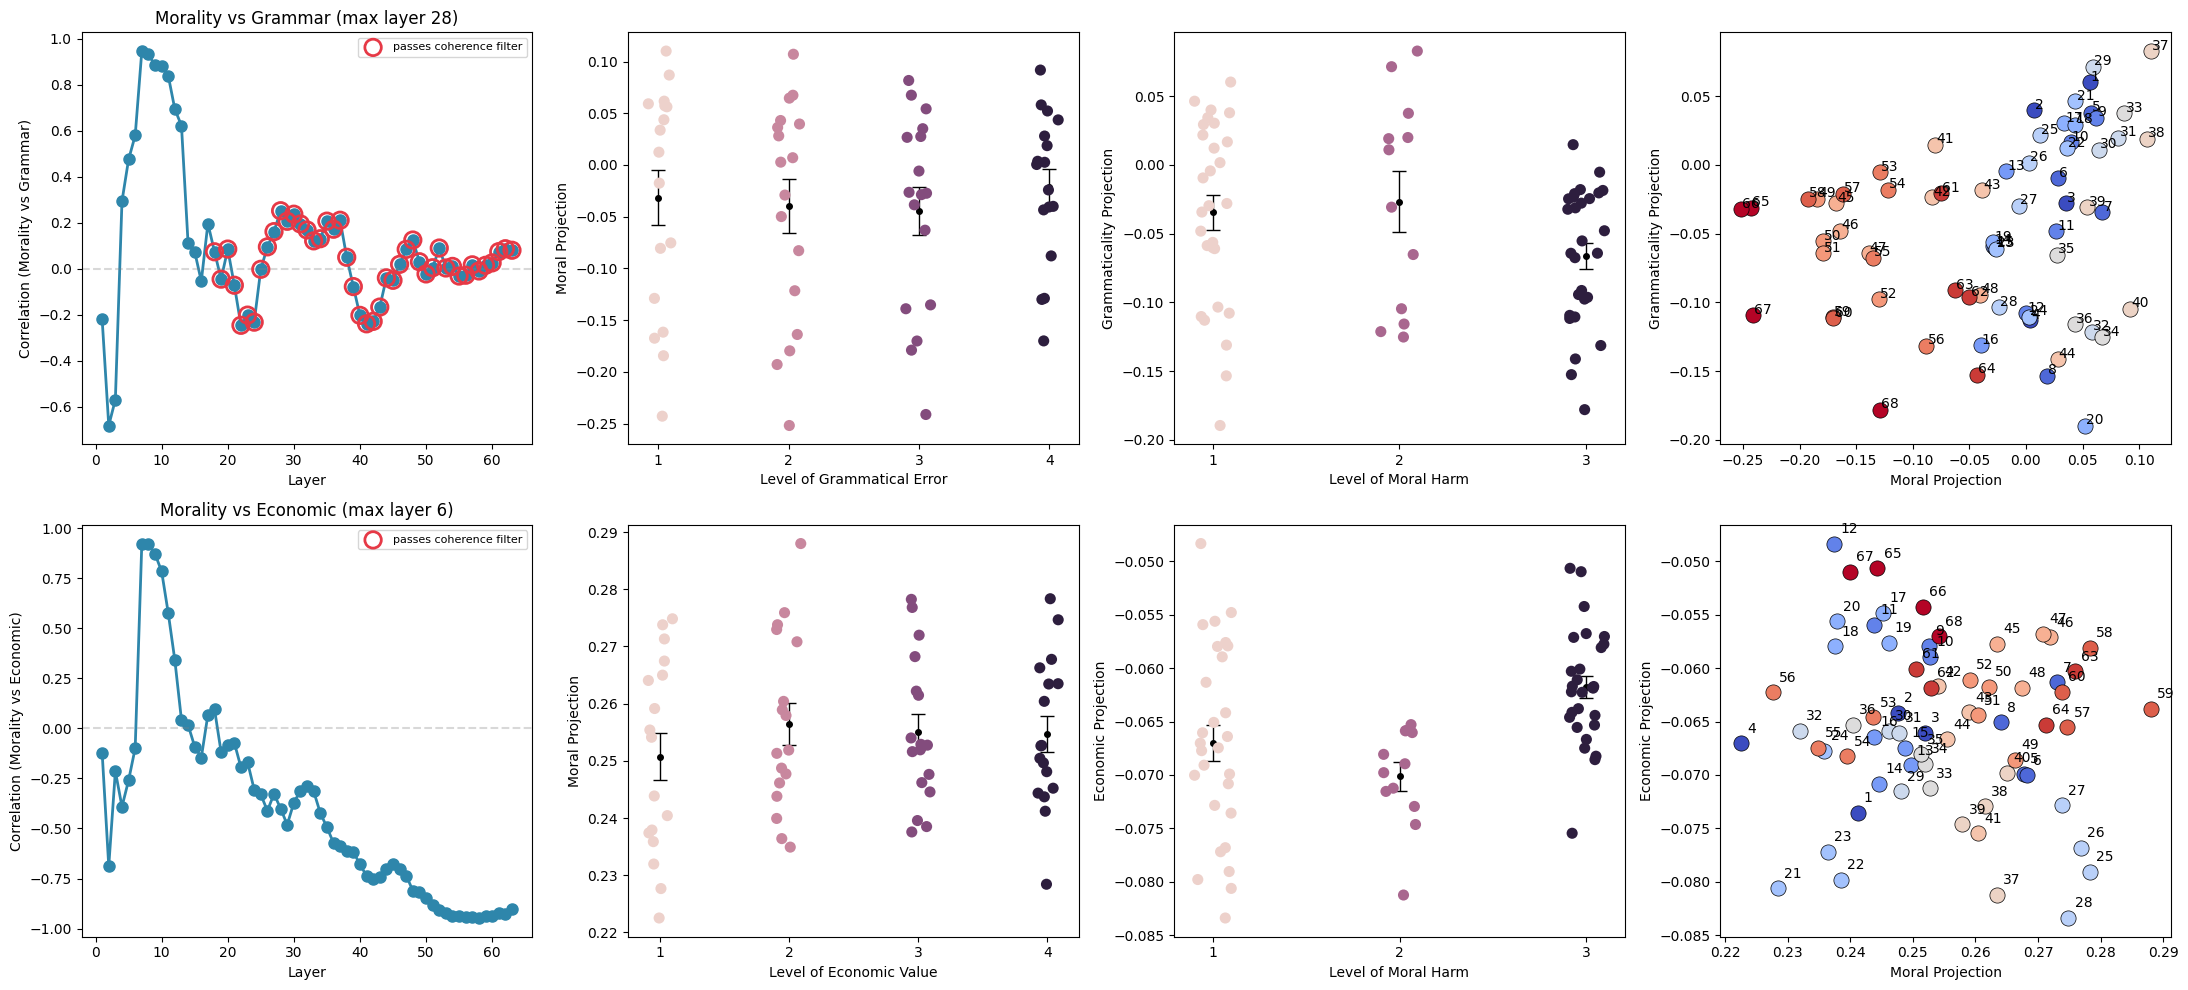

In [185]:
result_grammar, result_economic, max_layer_grammar, max_layer_economic = plot_combined_2x4(
    final_result_mg68, final_result_me68, max_layer_me=6,
)

In [186]:
try:
    # plot_morality_vs_second_projections(final_result_mg68, final_result_me68, num_layers=NUM_LAYERS)
    pass
except:
    print('Define NUM_LAYERS')

In [187]:
# cos_df = plot_direction_cosine_similarity(MODEL_NAME)

##### Statistics

In [188]:
print(f"=== Grammar (layer {max_layer_grammar}) [MoralGrammar68 stimuli] ===")
this_corr = np.corrcoef(result_grammar['syntax_v'], result_grammar['morality_v'])[0, 1]
print(f"  Correlation between grammar projections and moral projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_grammar['morality_rating'], result_grammar['morality_v'])[0, 1]
print(f"  Correlation between human morality ratings and moral projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_grammar['syntax_rating'], result_grammar['syntax_v'])[0, 1]
print(f"  Correlation between human grammar ratings and grammar projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_grammar['syntax_rating'], result_grammar['morality_v'])[0, 1]
print(f"  Correlation between human grammar ratings and moral projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_grammar['morality_rating'], result_grammar['syntax_v'])[0, 1]
print(f"  Correlation between human moral ratings and grammar projections: {this_corr:.3f}")

print(f"\n=== Economic (layer {max_layer_economic}) [MoralEconomic68 stimuli] ===")
this_corr = np.corrcoef(result_economic['economic_v'], result_economic['morality_v'])[0, 1]
print(f"  Correlation between economic projections and moral projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_economic['log_price'], result_economic['economic_v'])[0, 1]
print(f"  Correlation between log retail price and economic projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_economic['log_price'], result_economic['morality_v'])[0, 1]
print(f"  Correlation between log retail price and moral projections: {this_corr:.3f}")
this_corr = np.corrcoef(result_grammar['morality_rating'], result_economic['economic_v'])[0, 1]
print(f"  Correlation between human moral ratings and economic projections: {this_corr:.3f}")

=== Grammar (layer 28) [MoralGrammar68 stimuli] ===
  Correlation between grammar projections and moral projections: 0.253
  Correlation between human morality ratings and moral projections: 0.733
  Correlation between human grammar ratings and grammar projections: 0.805
  Correlation between human grammar ratings and moral projections: -0.009
  Correlation between human moral ratings and grammar projections: 0.276

=== Economic (layer 6) [MoralEconomic68 stimuli] ===
  Correlation between economic projections and moral projections: -0.099
  Correlation between log retail price and economic projections: 0.153
  Correlation between log retail price and moral projections: -0.359
  Correlation between human moral ratings and economic projections: -0.379


In [189]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(f"=== morality_v ~ morality_level * syntax_level | Grammar (layer {max_layer_grammar}) [MG68] ===")
m = ols('morality_v ~ C(morality_level) + C(syntax_level) + C(morality_level):C(syntax_level)',
        data=result_grammar).fit()
print(sm.stats.anova_lm(m, type=2).round(3))

print(f"\n=== syntax_v ~ morality_level * syntax_level | Grammar (layer {max_layer_grammar}) [MG68] ===")
m = ols('syntax_v ~ C(morality_level) + C(syntax_level) + C(morality_level):C(syntax_level)',
        data=result_grammar).fit()
print(sm.stats.anova_lm(m, type=2).round(3))

=== morality_v ~ morality_level * syntax_level | Grammar (layer 28) [MG68] ===
                                     df  sum_sq  mean_sq       F  PR(>F)
C(morality_level)                   2.0   0.456    0.228  94.973   0.000
C(syntax_level)                     3.0   0.005    0.002   0.733   0.536
C(morality_level):C(syntax_level)   6.0   0.023    0.004   1.593   0.166
Residual                           56.0   0.134    0.002     NaN     NaN

=== syntax_v ~ morality_level * syntax_level | Grammar (layer 28) [MG68] ===
                                     df  sum_sq  mean_sq       F  PR(>F)
C(morality_level)                   2.0   0.019    0.010  10.376   0.000
C(syntax_level)                     3.0   0.192    0.064  69.095   0.000
C(morality_level):C(syntax_level)   6.0   0.012    0.002   2.116   0.066
Residual                           56.0   0.052    0.001     NaN     NaN


In [190]:
print(f"=== morality_v ~ morality_level * economic_level | Economic (layer {max_layer_economic}) [ME68] ===")
m = ols('morality_v ~ C(morality_level) + C(economic_level) + C(morality_level):C(economic_level)',
        data=result_economic).fit()
print(sm.stats.anova_lm(m, type=2).round(3))

print(f"\n=== economic_v ~ morality_level * economic_level | Economic (layer {max_layer_economic}) [ME68] ===")
m = ols('economic_v ~ C(morality_level) + C(economic_level) + C(morality_level):C(economic_level)',
        data=result_economic).fit()
print(sm.stats.anova_lm(m, type=2).round(3))

=== morality_v ~ morality_level * economic_level | Economic (layer 6) [ME68] ===
                                       df  sum_sq  mean_sq      F  PR(>F)
C(morality_level)                     2.0   0.001    0.001  2.380   0.102
C(economic_level)                     3.0   0.000    0.000  0.453   0.716
C(morality_level):C(economic_level)   6.0   0.000    0.000  0.130   0.992
Residual                             56.0   0.013    0.000    NaN     NaN

=== economic_v ~ morality_level * economic_level | Economic (layer 6) [ME68] ===
                                       df  sum_sq  mean_sq      F  PR(>F)
C(morality_level)                     2.0   0.001      0.0  6.600   0.003
C(economic_level)                     3.0   0.000      0.0  0.850   0.473
C(morality_level):C(economic_level)   6.0   0.000      0.0  0.287   0.941
Residual                             56.0   0.003      0.0    NaN     NaN
